# 02 · Converting the FFN into a Mixture-of-Experts

**ERA V5 · Session 14 (Mixture-of-Experts)**, part 2 of 3.

A MoE layer keeps attention unchanged and replaces the one dense feed-forward with a **router + N SwiGLU experts**. For each token the router scores all experts, keeps the top-k, renormalises their weights, and sums the chosen experts' outputs:

$$y = \sum_{i \in \text{top-}k} g_i\, E_i(x),\qquad E_i(x) = W^{down}_i\big(\mathrm{SiLU}(W^{gate}_i x)\odot W^{up}_i x\big)$$

We use **8 experts, top-2** (as in Mixtral), each expert half the dense width, so the **active** parameters per token equal the dense model while **total** capacity is much larger.

In [1]:
import os, sys, json
REPO = None
for p in [os.getcwd(), os.path.dirname(os.getcwd())]:
    if os.path.exists(os.path.join(p, "moe")):
        REPO = p
        if p not in sys.path: sys.path.insert(0, p)
        break
assert REPO, "could not locate the moe package"
RESULTS = os.path.join(REPO, "results")
import torch
from moe.engine import get_device
DEVICE = get_device()
print("repo:", REPO, "| device:", DEVICE, "| torch:", torch.__version__)

repo: /Users/sokorada/Documents/ERA_V5/MixtureOfExperts | device: mps | torch: 2.13.0


In [2]:
from moe.model import GPT, GPTConfig
dense = GPT(GPTConfig(ffn='dense'))
moe   = GPT(GPTConfig(ffn='moe', routing='sparse'))
print(f"dense: {dense.num_params()/1e6:5.2f}M total = {dense.active_params()/1e6:.2f}M active")
print(f"moe  : {moe.num_params()/1e6:5.2f}M total, {moe.active_params()/1e6:.2f}M active "
      f"(top-2 of 8 experts)")
print(f"=> MoE has {moe.num_params()/dense.num_params():.1f}x the params at ~equal active compute")

dense: 14.46M total = 14.46M active
moe  : 46.32M total, 14.47M active (top-2 of 8 experts)
=> MoE has 3.2x the params at ~equal active compute


## Load balancing
Left alone, the router sends most tokens to a few favourites and the rest die. The Switch-style auxiliary loss `L_aux = α·N·Σ fᵢPᵢ` (fraction routed × mean probability) pushes the load even. We log the busiest-expert load (1.0 = perfectly balanced) and the count of dead experts.

## Sparse routing is exact
The MoE dispatches each token only to its top-k experts. We check that this sparse dispatch equals the simple 'compute every expert then mask' reference (same weights).

In [3]:
import copy, torch
torch.manual_seed(0)
m = GPT(GPTConfig(ffn='moe', routing='sparse')).eval()
mm = copy.deepcopy(m)
for blk in mm.blocks:
    if blk.is_moe: blk.ff.routing = 'masked'
x = torch.randint(0,256,(2,64))
with torch.no_grad():
    o1,_,_ = m(x); o2,_,_ = mm(x)
print('sparse vs masked max abs diff:', (o1-o2).abs().max().item())

sparse vs masked max abs diff: 3.5762786865234375e-07


## Short live demo — MoE trains and balances
Watch `maxload` fall toward 1.0 and `dead` stay at 0.

In [4]:
from moe.engine import train_run
from moe.data import prepare
train_bin, val_bin = prepare()
cfg = GPTConfig(ffn='moe', routing='sparse')
demo,_ = train_run(cfg, 'demo_moe', batch_size=16, token_budget=16*512*120,
                   train_bin=train_bin, val_bin=val_bin, device=DEVICE, log_every=30)
print(demo.summary())

[data] cached: /Users/sokorada/Documents/ERA_V5/MixtureOfExperts/data/train.bin, /Users/sokorada/Documents/ERA_V5/MixtureOfExperts/data/val.bin


[demo_moe] step     0/120 loss 5.5948 6,734 tok/s aux 0.151 maxload 3.29 dead 0


[demo_moe] step    30/120 loss 2.6424 5,858 tok/s aux 0.123 maxload 1.56 dead 0


[demo_moe] step    60/120 loss 2.3575 6,450 tok/s aux 0.120 maxload 1.34 dead 0


[demo_moe] step    90/120 loss 2.3577 7,521 tok/s aux 0.120 maxload 1.23 dead 0


[demo_moe] step   119/120 loss 2.3139 8,823 tok/s aux 0.120 maxload 1.18 dead 0


demo_moe: ffn=moe params=46.32M (active 14.47M) val_loss=2.3281 speed=8,823 tok/s


## Full run (loaded from results/moe.json)

In [5]:
r = json.load(open(os.path.join(RESULTS,'moe.json')))
print(f"final train loss: {r['final_train_loss']:.4f}")
print(f"final val loss  : {r['final_val_loss']:.4f}")
print(f"speed           : {r['tokens_per_sec']:,.0f} tok/s")
last = [x for x in r['history'] if 'max_load' in x][-1]
print(f"final balance   : busiest load {last['max_load']:.2f}x, dead experts {last['dead']}")

final train loss: 0.8850
final val loss  : 0.8902
speed           : 17,314 tok/s
final balance   : busiest load 1.07x, dead experts 0


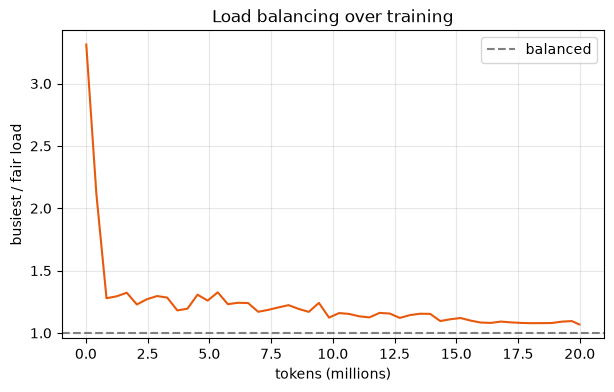

In [6]:
import matplotlib.pyplot as plt
h=[x for x in r['history'] if 'max_load' in x]
plt.figure(figsize=(7,4))
plt.plot([x['tokens']/1e6 for x in h],[x['max_load'] for x in h], color='#E8590C')
plt.axhline(1.0, ls='--', color='grey', label='balanced')
plt.xlabel('tokens (millions)'); plt.ylabel('busiest / fair load'); plt.legend()
plt.title('Load balancing over training'); plt.grid(alpha=0.3); plt.show()

➡️ Next: **03 · Comparison & report**.